/var/folders/g1/p80rk3p12_qdwshtmj0bt6p00000gn/T/ipykernel_67408/1090979074.py:14: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  llm = Ollama(model="exaone3.5:7.8b")


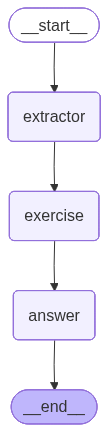


최종 응답:

### 사용자 상태 분석 및 운동 추천

- **증상 설명**
  - **체력 저하**: 최근 활동량 감소나 스트레스로 인해 에너지 수준이 낮아진 상태입니다.
  - **체중 증가**: 대사량 감소와 활동 부족으로 인해 체중이 증가하고 있습니다.

- **추천 운동**
  - **산책**: 가벼운 강도의 유산소 운동으로, 관절에 부담이 적고 체력 회복에 도움이 됩니다.
  - **요가**: 유연성과 근력을 향상시키며, 스트레스 해소에도 효과적입니다.
  - **수영**: 전신 운동으로 체력 증진과 체중 관리에 좋으며, 관절에 무리가 적습니다.
  - **자전거 타기**: 하체 근육 강화와 심폐기능 향상에 도움이 됩니다.
  - **인터벌 트레이닝**: 강도 높은 운동과 휴식을 반복하여 효율적인 에너지 소비와 체력 향상을 도모합니다.

- **운동 효과**
  - **체력 향상**: 꾸준한 운동으로 체력이 점차 회복되고, 일상 활동에 대한 에너지 수준이 향상됩니다.
  - **체중 관리**: 규칙적인 운동과 함께 건강한 식습관을 병행하면 체중 조절에 효과적입니다.
  - **스트레스 해소**: 요가와 산책 등은 스트레스를 줄이고 정신 건강을 개선합니다.
  - **근력 및 유연성 증가**: 요가와 수영은 근육의 유연성을 높이고, 자전거 타기와 인터벌 트레이닝은 근력을 강화합니다.

- **운동 시 주의사항**
  - **시작 전 의사 상담**: 체력 저하와 체중 증가 증상이 있으므로 운동 전 의사와 상의하는 것이 중요합니다.
  - **점진적 증가**: 처음부터 과도한 강도의 운동은 피하고, 체력에 맞게 점진적으로 강도를 높여갑니다.
  - **적절한 휴식**: 운동과 충분한 휴식을 병행하여 부상 위험을 줄입니다.
  - **수분 섭취**: 운동 중 충분한 수분 섭취로 탈수를 방지합니다.
  - **편안한 복장**: 편안하고 적절한 운동복과 신발을 착용하여 부상 위험을 최소화합니다.


In [1]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, END
from typing import TypedDict

# 1. 상태 정의
class AgentState(TypedDict):
    query: str                 # 사용자 질문
    symptoms: str              # 추출된 증상
    exercise_list: str         # 추천 운동 리스트
    result: str                # 최종 응답

# 2. LLM 초기화
llm = Ollama(model="exaone3.5:7.8b")

# 3. 추출 에이전트
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 현재 상태나 증상에 해당하는 내용을 추출하세요.
결과는 쉼표로 구분된 문자열로 출력하세요.

질문:
{query}
""")

# 증상 추출 함수
def extractor_agent(state: AgentState):
    chain = extractor_prompt | llm
    symptoms = chain.invoke({"query": state["query"]})

    return {**state, "symptoms": symptoms.strip()}

# 4. 운동 추천 에이전트
exercise_prompt = PromptTemplate.from_template("""
다음 증상들을 개선하는 데 도움이 되는 운동 5개를 추천하세요.

증상:
{symptoms}

운동 이름만 쉼표로 구분해서 출력하세요.
""")

# 운동 추천 함수
def exercise_agent(state: AgentState):
    chain = exercise_prompt | llm
    exercises = chain.invoke({"symptoms": state["symptoms"]})

    return {**state, "exercise_list": exercises.strip()}

# 5. 최종 답변 생성 에이전트
answer_prompt = PromptTemplate.from_template("""
사용자의 상태는 다음과 같습니다.

[증상]
{symptoms}

[추천 운동]
{exercise_list}

위 내용을 바탕으로 아래 형식처럼 개조식으로 설명하세요.

- 증상 설명
- 추천 운동
- 운동 효과
- 운동 시 주의사항

반드시 한국어로 출력하세요.
""")

# 최종 답변 함수
def answer_agent(state: AgentState):
    chain = answer_prompt | llm
    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercise_list": state["exercise_list"]
        })

    return {**state, "result": answer.strip()}

# 6. LangGraph 정의

graph = StateGraph(AgentState)

# 노드 추가
graph.add_node("extractor", extractor_agent)
graph.add_node("exercise", exercise_agent)
graph.add_node("answer", answer_agent)

# 시작 노드
graph.set_entry_point("extractor")

# 노드 연결
graph.add_edge("extractor", "exercise")
graph.add_edge("exercise", "answer")
graph.add_edge("answer", END)

# 그래프 컴파일
app = graph.compile()

# 7. 그래프 시각화
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

# 8. 실행
query = "체력이 안 좋고 살이 계속 찌는데 어떤 운동을 하면 좋을까?"
result = app.invoke({"query": query})

# 9. 결과 출력
print("\n최종 응답:\n")
print(result["result"])